# BFG Demo Notebook


This notebook walks through the BFG pipeline output.
All results were pre-computed and are loaded from files bundled in this repository.

**Article**: p66Shc Mediates SUMO2-induced Endothelial Dysfunction (bioRxiv, cell biology, CC0)  
**Article ID**: 577109  
**Figures processed**: 8  
**Backends**: Tesseract OCR, ViT-GPT2 captioning, d4data NER (the defaults; see report section 4.9)

## Contents

1. Load and inspect the pre-computed annotation
2. Inspect the entities of one figure, with their source tags
3. Show one figure image alongside its annotation
4. Display the evaluation results from the 30-figure gold set

In [28]:
import json
import sys
from pathlib import Path

# Add src to path so bfg can be imported without installation.
ROOT = Path().resolve().parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

ARTEFACTS = ROOT / 'artefacts'
EVAL_RESULTS = ROOT / 'eval_results'

## 1.annotation for article 577109

In [29]:
annotation_path = ARTEFACTS / '577109_annotation.json'
annotation = json.loads(annotation_path.read_text(encoding='utf-8'))

print('Article ID:', annotation['article_id'])
print('Title:', annotation['title'])
print('Figures:', len(annotation['figures']))
print()
print('Abstract (first 200 chars):')
print(annotation['abstract'][:200])

Article ID: 9581c585-9350-1014-b05e-d2f5ac961b22
Title: p66Shc Mediates SUMO2-induced Endothelial Dysfunction
Figures: 8

Abstract (first 200 chars):
Abstract Background Sumoylation is a post-translational modification that can regulate different physiological functions. Increased sumoylation, specifically conjugation of SUMO2/3 (small ubiquitin-li


In [30]:
import pandas as pd

rows = []
for fig in annotation['figures']:
    ner_data = fig['ner'].get('data', {})
    entities = ner_data.get('entities', [])
    ocr_data = fig['ocr'].get('data', {})
    vision_data = fig['vision'].get('data', {})
    rows.append({
        'fig_id': fig['fig_id'],
        'ocr_chars': ocr_data.get('char_count', 0),
        'ocr_status': fig['ocr']['status'],
        'vision_caption': (vision_data.get('caption') or '')[:60],
        'ner_entities': len(entities),
        'ner_status': fig['ner']['status'],
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

fig_id  ocr_chars ocr_status                                               vision_caption  ner_entities ner_status
  fig1        531         ok        a series of photos showing different types of objects           105         ok
  fig2        667         ok a series of photographs showing a variety of different types            71         ok
  fig3       1126         ok                    a collage of photos of various appliances           147         ok
  fig4        838         ok a series of photos showing a variety of different types of r           105         ok
  fig5        708         ok       a collage of photos showing different types of objects           103         ok
  fig6       1086         ok        a series of photos showing different types of objects           189         ok
  fig7        487         ok a series of images showing different types of electronic equ           132         ok
  fig8        523         ok a series of photos showing a series of different co

## 2. Inspect entities for one figure

In [31]:
# Pick the figure with the most entities.
best = max(annotation['figures'], key=lambda f: len(f['ner'].get('data', {}).get('entities', [])))
print('Figure:', best['fig_id'])
print('Caption:', best['caption'][:120])
print()
print('OCR text (first 200 chars):')
print((best['ocr'].get('data', {}).get('text') or '')[:200])
print()
print('Entities with source tags:')
for ent in best['ner'].get('data', {}).get('entities', [])[:15]:
    print(f"  {ent.get('word', ''):<20} {ent.get('entity_group', ''):<12} source={ent.get('source', 'unknown')}")

Figure: fig6
Caption: p66ShcK81R knockin (KI) are resistant to SUMO2-induced endothelial dysfunction. (A) DNA sequencing data from a p66ShcK81

OCR text (first 200 chars):
Apal

5G6G6GGGCGCCTGGGGCCCAgAGGaGAGCCAGGAAAGGECT!
I A n nl J 1 J A
i t T t T t T t

cCCCCCGCGGACCCCGGgTcTCCtCTCGGTCCTTTCCGAI

Exon 1: Coding

Repair Oligo

K81R

165 170 175

5G6G6GGGCGCCTGGGGCCcCAgAG

Entities with source tags:
  p66ShcK81R           Diagnostic_procedure source=caption
  KI                   Diagnostic_procedure source=caption
  SUMO2                Detailed_description source=caption
  DNA sequencing       Diagnostic_procedure source=caption
  point mutation       Sign_symptom source=caption
  amino acid change    Sign_symptom source=caption
  silent               Detailed_description source=caption
  mutation             Coreference  source=caption
  ApaI                 Diagnostic_procedure source=caption
  endonuclease         Diagnostic_procedure source=caption
  DNA gel              Diagnostic

## 3. Figure image alongside annotation

The figure below is `fig6` from article 577109, extracted from the source `.meca` archive. It is also one of the 30 gold-set figures (index 13 in `annotation_browser.ipynb`).

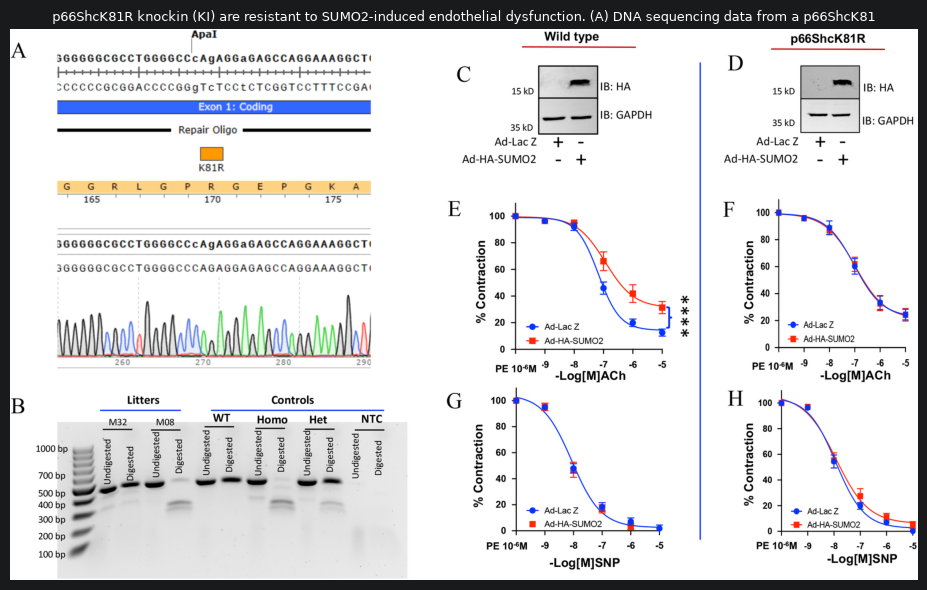

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = ARTEFACTS / '577109_fig6.png'
if img_path.exists():
    img = Image.open(img_path)
    fig_ann = next((f for f in annotation['figures'] if 'fig6' in f['fig_id'].lower()), None)
    caption = fig_ann['caption'][:120] if fig_ann else 'caption not found'
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, fontsize=9, wrap=True)
    plt.tight_layout()
    plt.show()
else:
    print('Image not found at', img_path)

## 4. Evaluation results from the 30-figure gold set

These results are from `eval_results/`, written by `evaluation.ipynb`. The cells below print Tables 5.1 to 5.3 of the report; `summary.md`, printed last, covers all six tables (5.1 to 5.6) with their 95% bootstrap intervals. The report figures are in `eval_results/figures/`.

In [33]:
print('=== Table 5.1: OCR evaluation (RQ1) ===')
ocr_df = pd.read_csv(EVAL_RESULTS / 'table_5_1_ocr.csv')
print(ocr_df.to_string(index=False))
print()

=== Table 5.1: OCR evaluation (RQ1) ===
  backend  N      CER   CER_lo   CER_hi      WER   WER_lo   WER_hi  word_recall  word_recall_lo  word_recall_hi  word_precision  word_precision_lo  word_precision_hi
tesseract 30 0.658187 0.624881 0.691023 0.893237 0.834654 0.951883     0.366880        0.298486        0.446191        0.424653           0.350844            0.50208
    trocr 30 0.997223 0.995947 0.998235 0.999734 0.999045 1.000000     0.000266        0.000000        0.000955        0.033333           0.000000            0.10000



In [34]:
print('=== Table 5.2: Caption-only vs caption+OCR ablation (RQ2) ===')
abl_df = pd.read_csv(EVAL_RESULTS / 'table_5_2_ablation.csv')
print(abl_df.to_string(index=False))
print()

=== Table 5.2: Caption-only vs caption+OCR ablation (RQ2) ===
                  backend          context   match  N        P     P_lo     P_hi        R     R_lo     R_hi       F1    F1_lo    F1_hi  TP   FP  FN  OCR_only_TP  strings_per_fig
d4data-biomedical-ner-all     caption_only   exact 30 0.234070 0.190554 0.280314 0.395604 0.315654 0.467622 0.294118 0.244644 0.338363 180  589 275            0        25.633333
d4data-biomedical-ner-all caption_plus_ocr   exact 30 0.130765 0.100487 0.164181 0.529670 0.457327 0.591802 0.209748 0.167466 0.253460 241 1602 214           50        61.433333
d4data-biomedical-ner-all     caption_only overlap 30 0.469441 0.402477 0.528211 0.632967 0.536228 0.719546 0.539076 0.473303 0.590841 288  408 167            0        25.633333
d4data-biomedical-ner-all caption_plus_ocr overlap 30 0.270212 0.226708 0.318634 0.767033 0.691741 0.829104 0.399638 0.347493 0.453031 349 1345 106           50        61.433333



In [35]:
print('=== Table 5.3: NER model comparison (RQ3) ===')
ner_df = pd.read_csv(EVAL_RESULTS / 'table_5_3_ner_comparison.csv')
print(ner_df.to_string(index=False))
print()

=== Table 5.3: NER model comparison (RQ3) ===
                  backend          context   match  N        P     P_lo     P_hi        R     R_lo     R_hi       F1    F1_lo    F1_hi  TP   FP  FN  OCR_only_TP  strings_per_fig
d4data-biomedical-ner-all caption_plus_ocr   exact 30 0.130765 0.100487 0.164181 0.529670 0.457327 0.591802 0.209748 0.167466 0.253460 241 1602 214           50        61.433333
            bert-base-ner caption_plus_ocr   exact 30 0.386364 0.286879 0.504003 0.112088 0.080644 0.148150 0.173765 0.129817 0.220859  51   81 404            5         4.400000
                 scispacy caption_plus_ocr   exact 30 0.164033 0.134994 0.193772 0.661538 0.616426 0.700702 0.262882 0.223306 0.302014 301 1534 154           31        61.166667
d4data-biomedical-ner-all caption_plus_ocr overlap 30 0.270212 0.226708 0.318634 0.767033 0.691741 0.829104 0.399638 0.347493 0.453031 349 1345 106           50        61.433333
            bert-base-ner caption_plus_ocr overlap 30 0.621212 0

In [36]:
print('=== Summary (eval_results/summary.md) ===')
print((EVAL_RESULTS / 'summary.md').read_text(encoding='utf-8'))

=== Summary (eval_results/summary.md) ===
# BFG evaluation results

RQ1 to RQ3 use the 30 of 30 gold figures marked done, with 455 unique gold names, 390 of them in the caption and 65 only in the image text. RQ4 uses all 30 figures. Intervals are 95% percentile intervals from 2000 figure-level bootstrap resamples (seed 1234).

## Table 5.1: OCR against the gold image text (RQ1)

| backend   |   N |   CER |   CER_lo |   CER_hi |   WER |   WER_lo |   WER_hi |   word_recall |   word_recall_lo |   word_recall_hi |   word_precision |   word_precision_lo |   word_precision_hi |
|:----------|----:|------:|---------:|---------:|------:|---------:|---------:|--------------:|-----------------:|-----------------:|-----------------:|--------------------:|--------------------:|
| tesseract |  30 | 0.658 |    0.625 |    0.691 | 0.893 |    0.835 |    0.952 |         0.367 |            0.298 |            0.446 |            0.425 |               0.351 |               0.502 |
| trocr     |  30 | 0.997 |